In [ ]:
from plotter import All_Domain_Plotter
import pandas as pd
import json

In [2]:
all_domains = All_Domain()
plotter = All_Domain_Plotter(all_domains)

Loading existing results from all_city_data/all_cities/domain_counts.json


Fetching counts:   0%|          | 0/40 [00:00<?, ?domain/s]


Summary:
Successful: 40/40 domains
Failed: 0 domains
(Timeouts: 0)
Total datasets: 25,430
Results saved to all_city_data/all_cities/domain_counts.json


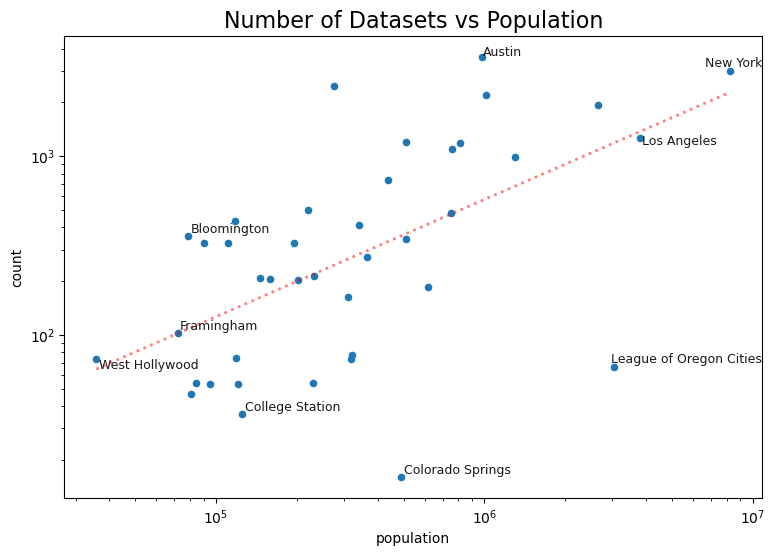

In [3]:
plotter.pop_count()

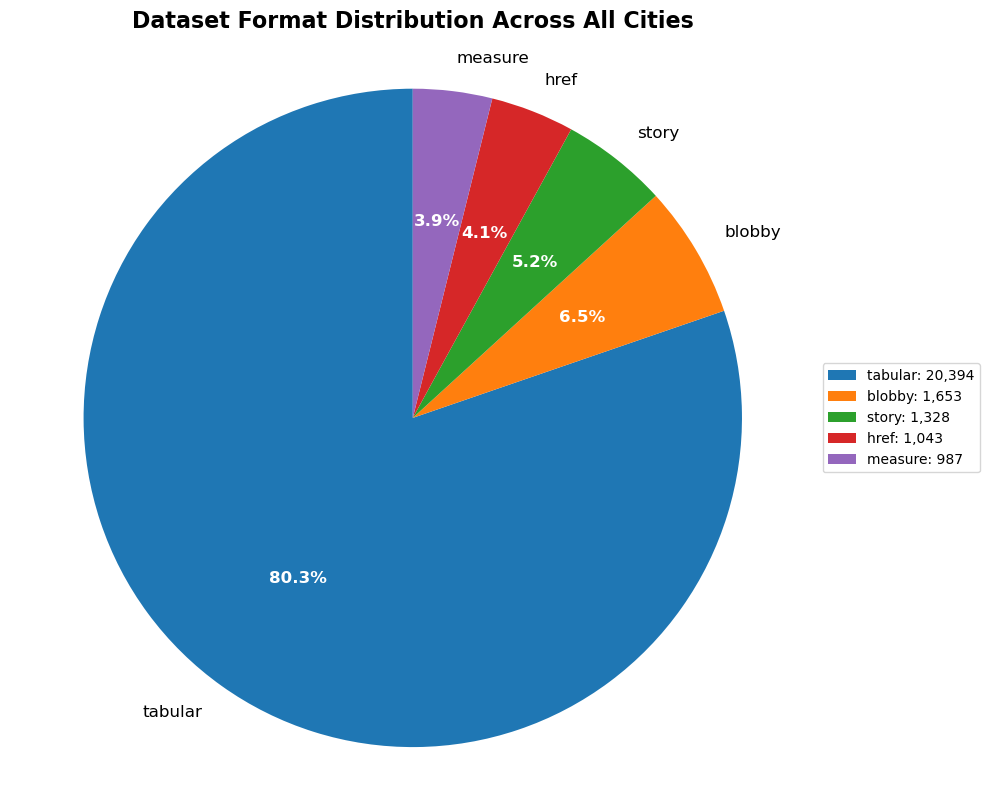

In [3]:
plotter.plot_format_distribution()

Calculating tabular percentages for each city...


Processing cities:   0%|          | 0/40 [00:00<?, ?city/s]

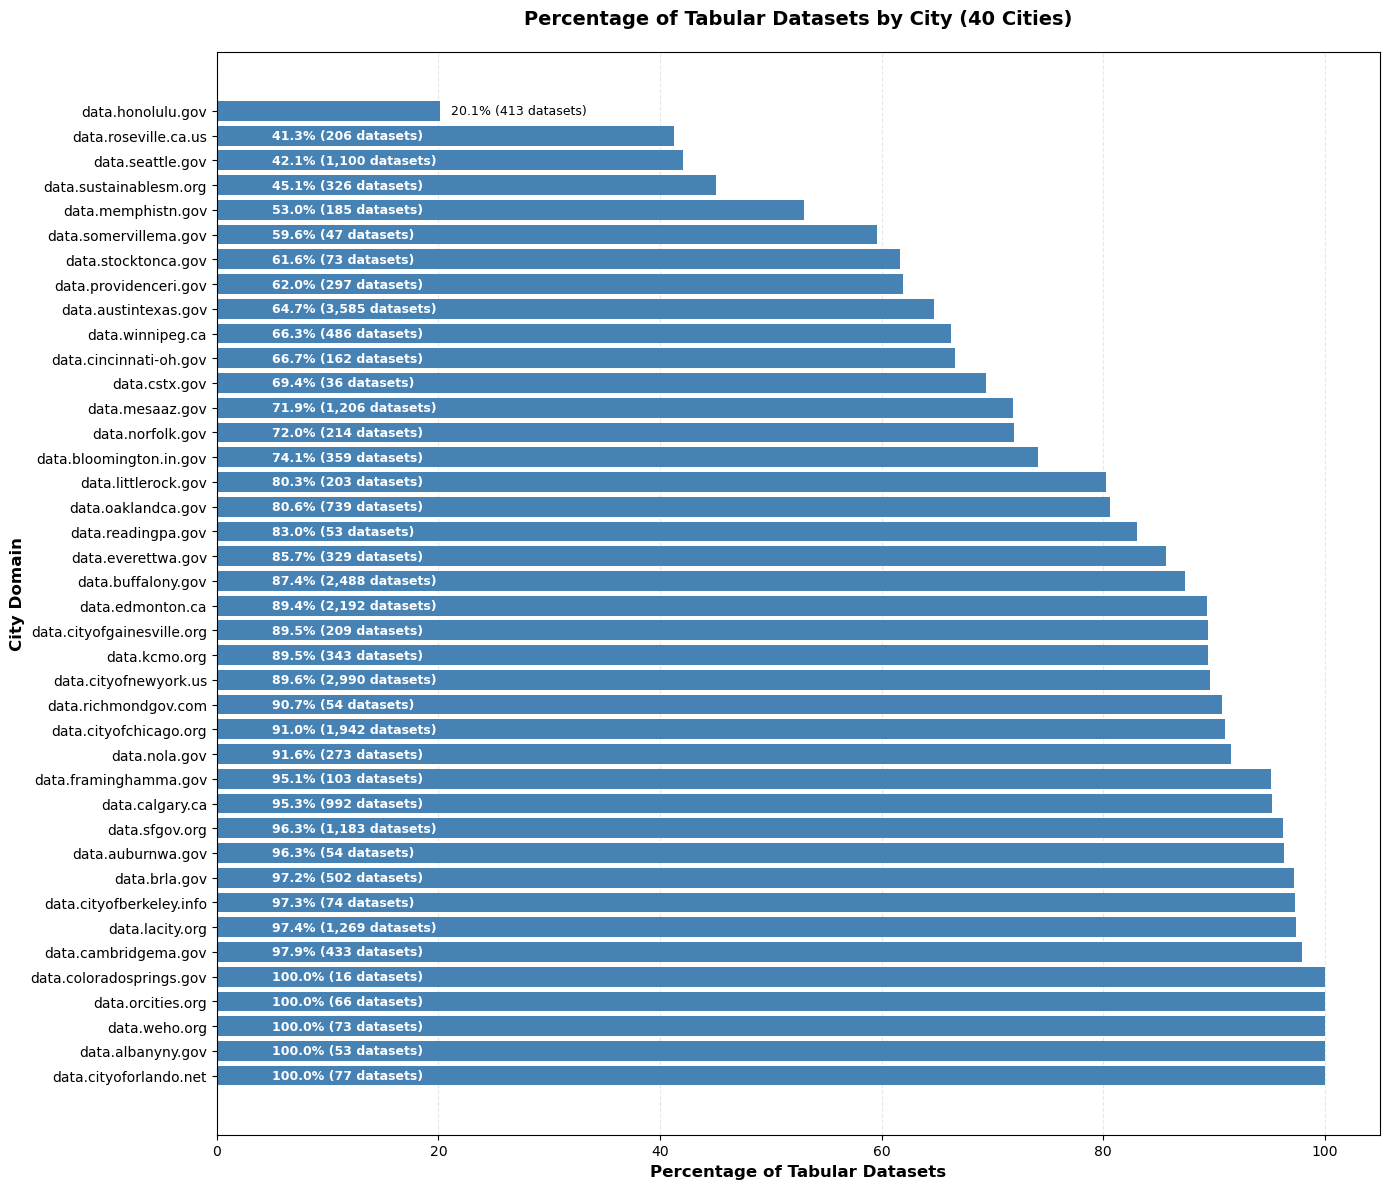

In [3]:
plotter.plot_tabular_percentage_by_city()

In [3]:
df = plotter.data_count_cat()

Loading existing results from all_city_data/all_cities/domain_counts.json


Fetching counts:   0%|          | 0/40 [00:00<?, ?domain/s]


Summary:
Successful: 40/40 domains
Failed: 0 domains
(Timeouts: 0)
Total datasets: 25,430
Results saved to all_city_data/all_cities/domain_counts.json
Table saved to all_city_data/all_cities/plots/City_Set_Count_And_Categories.html


In [3]:
plotter.row_count()

Table saved to all_city_data/all_cities/plots/Row_Count_Data.html


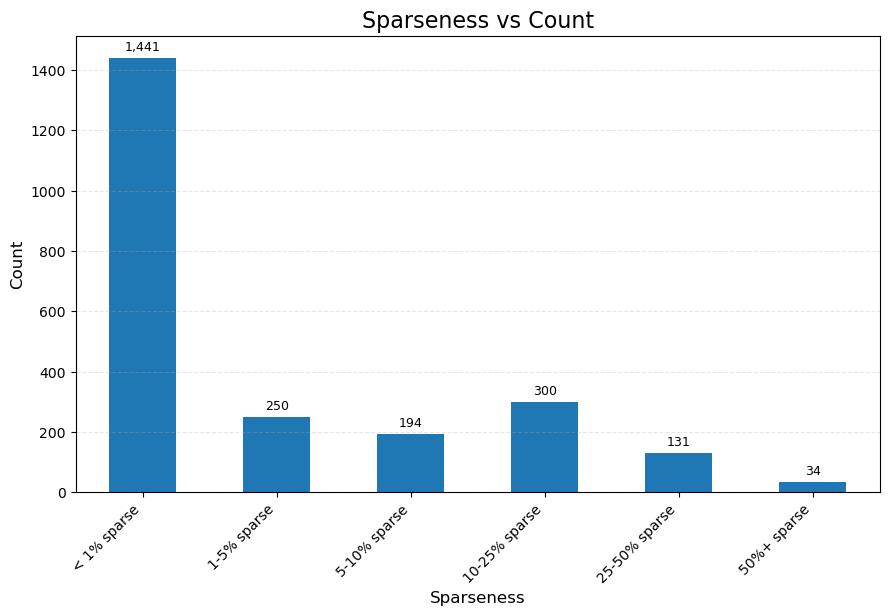

In [5]:
# Can select domain
plotter.bar_graph("sparseness") # attribute, download, view, sparseness, type

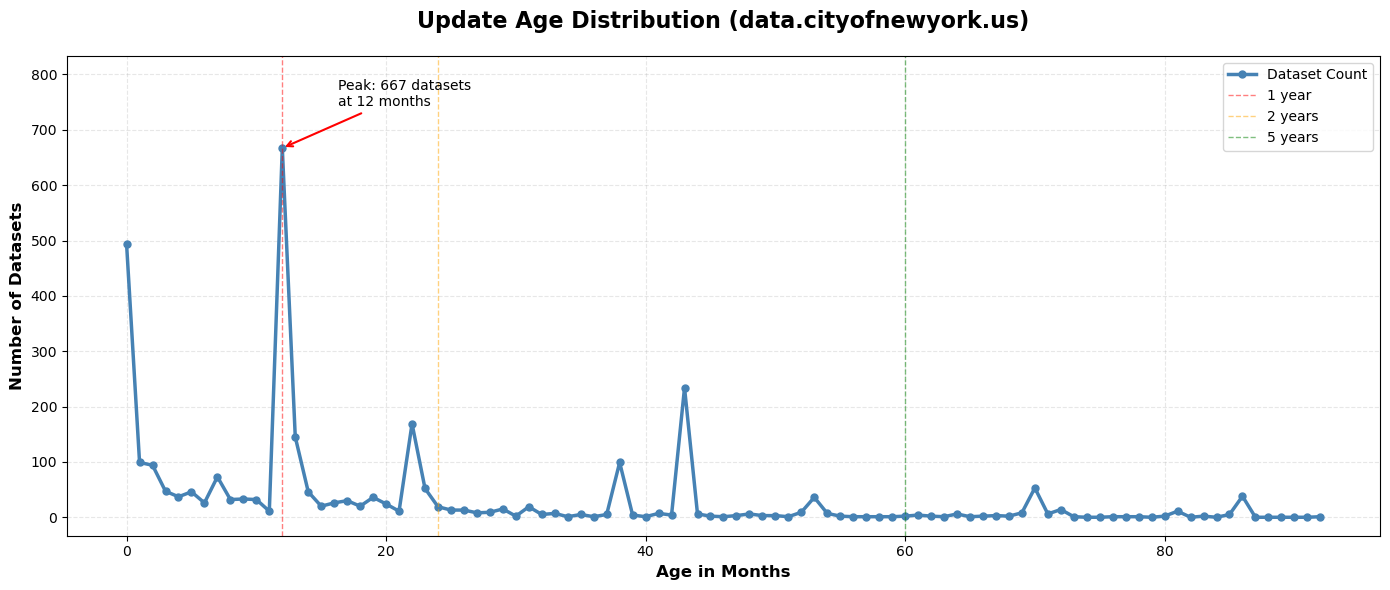

In [3]:
# Can select domain
plotter.line_graph("update") # publication, update

In [5]:
from socrata_interface.plotter import All_Domain_Plotter
from socrata_interface.io import read_data
from models.data_summary import DataSummary

plotter = All_Domain_Plotter("asdfg")
summary_dct = read_data("weho", "12345", "summary")
summary = DataSummary.from_dict(summary_dct)


In [6]:
summary_dct

{'count': 73,
 'asset_type': {'dataset': 37, 'chart': 24, 'filter': 6, 'map': 6},
 'category': {'Expenditures': 10,
  'Revenues': 4,
  'Infrastructure': 3,
  'Housing': 2,
  'Traffic': 2,
  'Parking': 2,
  'CIP': 2,
  'Contracts': 1,
  'Filming': 1,
  'Art': 1,
  'Business': 1,
  'Special Events': 1},
 'display': {'table': 43,
  'visualization_canvas_chart': 24,
  'visualization_canvas_map': 6},
 'download_count': {'0-100': 33, '100-1K': 17, '1K-10K': 19, '10K+': 4},
 'last_update': {'0': 6,
  '4': 2,
  '9': 3,
  '11': 2,
  '14': 1,
  '17': 1,
  '19': 2,
  '21': 1,
  '30': 15,
  '36': 1,
  '49': 1,
  '51': 3,
  '54': 10,
  '61': 1,
  '74': 1,
  '75': 2,
  '79': 1,
  '84': 1,
  '87': 3,
  '98': 1,
  '100': 1,
  '110': 1,
  '112': 6,
  '113': 1,
  '122': 1,
  '124': 2,
  '126': 1,
  '129': 2},
 'publication_date': {'11': 4,
  '16': 1,
  '24': 1,
  '31': 1,
  '36': 1,
  '39': 1,
  '49': 1,
  '51': 5,
  '52': 1,
  '61': 1,
  '73': 1,
  '75': 2,
  '78': 2,
  '79': 18,
  '83': 1,
  '86': 1,


In [8]:
from wordcloud import WordCloud

In [9]:
wc = WordCloud(width = 800, height = 400, background_color="white")

In [11]:
cloud = plotter.tagcloud(summary, wc, log=False)

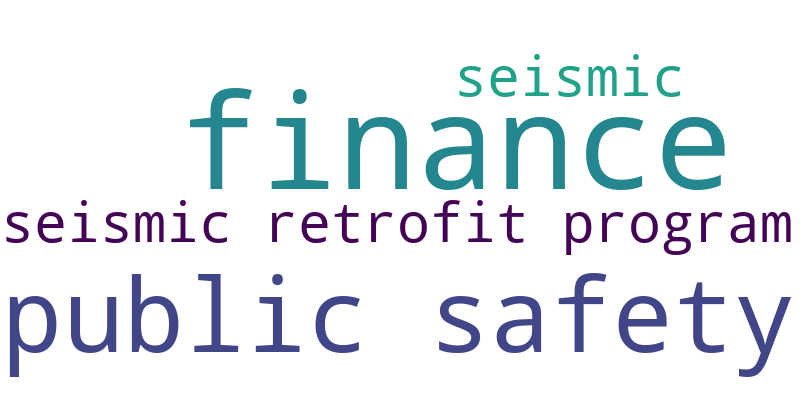

In [13]:
cloud.to_image()

In [12]:
from datasketch import HyperLogLog, MinHash, MinHashLSHEnsemble

# 1. Create Data
small_set = [f"usr_{i}" for i in range(500)]
large_set = [f"usr_{i}" for i in range(1000)]

# 2. Build MinHashes (MUST share seed & num_perm)
mh_small = MinHash(num_perm=128, seed=1)
for item in small_set:
    mh_small.update(item.encode("utf-8"))

mh_large = MinHash(num_perm=128, seed=1)
for item in large_set:
    mh_large.update(item.encode("utf-8"))

# 3. Direct Jaccard Check (Sanity Check)
print("Direct MinHash Jaccard:", mh_large.jaccard(mh_small))
# Expected: ~0.10

# 4. Build LSH Ensemble
ensemble = MinHashLSHEnsemble(threshold=0.7, num_part=32)

# Index both using EXACT set sizes first (bypassing HLL)
ensemble.index(
    [
        ("ds_users::user_id", mh_small, 100),
        ("ds_orders::customer_id", mh_large, 1000),
    ]
)

# 5. Query Small against Large
results = list(ensemble.query(mh_large, 1000))
print("LSH Ensemble Query Results:", results)

Direct MinHash Jaccard: 0.515625
LSH Ensemble Query Results: ['ds_orders::customer_id']
